In [13]:
import pandas as pd
import matplotlib.pyplot as plt

path = "docs/server_logs.csv" # Ruta del archivo CSV
df = pd.read_csv(path) # Carga del archivo CSV

df['timestamp_event'] = pd.to_datetime(df['timestamp_event']) # Convierte la columna timestamp_event a tipo datetime

df['is_bad_event'] = df['severity'].isin(['ERROR', 'CRITICAL']) | (df['status_code'] >= 500) # Define lo que es un "bad event" según el criterio: severidad de ERROR/CRITICAL o status >= 500

print("Libreria y data cargada correctamente")

Libreria y data cargada correctamente


### Exploración inicial
- ¿Cuántos logs hay en total?
- ¿Qué severidad aparece más?
- ¿Qué servicio genera más logs?
- ¿Qué servicio genera menos logs?
- ¿Cuál es el mensaje más repetido?
- ¿Cuál es el mensaje “malo” más repetido? (bad events)


In [14]:
total_logs = len(df) # Total de Logs
most_common_severity = df['severity'].value_counts().head() # Severidad mas frecuente
service_most_logs = df['service_name'].value_counts().idxmax() # Servicio con mas logs
service_least_logs = df['service_name'].value_counts().idxmin() # Servicio con menos logs
most_common_message = df['message'].value_counts().head(3) # Mensajes mas repetidos
most_common_bad_message = df[df['is_bad_event']]['message'].value_counts().head(5) # Top 5 mensajes malos

print(f"Total de logs: {total_logs}\n")
print(f"Severity mas frecuente: {most_common_severity}\n")
print(f"Servicio con mas Logs: {service_most_logs}\n")
print(f"Servicio con menos Logs: {service_least_logs}\n")
print(f"Mensaje mas repetido: {most_common_message}\n")
print(f"Top 5 Mensajes Malos: {most_common_bad_message}\n")

Total de logs: 5795

Severity mas frecuente: severity
INFO        3542
WARN        1358
ERROR        775
CRITICAL     120
Name: count, dtype: int64

Servicio con mas Logs: api-gateway

Servicio con menos Logs: notification-service

Mensaje mas repetido: message
Health check OK             1196
Background job completed    1185
Request completed           1161
Name: count, dtype: int64

Top 5 Mensajes Malos: message
Order creation failed - inventory lock timeout    197
Payment gateway unavailable                       103
Database deadlock detected                         99
Checkout failed - upstream payment timeout         88
Possible credential stuffing detected              69
Name: count, dtype: int64



### Detección del momento crítico
- window_start
- total_events
- bad_events
- bad_rate Seleccionar el momento crítico (top 1 por regla).


In [15]:
time_grouper = pd.Grouper(key='timestamp_event', freq='5min') # Agrupa los datos en ventanas de 5 minutos

df_time_windows = (
    df.groupby(time_grouper).agg(
        total_events = ('timestamp_event', 'count'),
        bad_events = ('is_bad_event', 'sum')
    ).reset_index().rename(columns={'timestamp_event': 'window_start'})
) # Agrupa los datos por ventana de 5 minutos y cuenta el total de eventos y bad events

df_time_windows['bad_rate'] = (
    df_time_windows['bad_events'] / df_time_windows['total_events']
) # Calcula el bad rate

df_windows_filtered = df_time_windows.loc[
    df_time_windows['total_events'] >= 20
] # Filtra las ventanas que tengan al menos 20 eventos

df_windows_top5 = (df_windows_filtered.sort_values('bad_rate', ascending=False).head(5)) # Ordena las ventanas por bad rate y toma las top 5
print(f"Top 5:\n{df_windows_top5}")

sr_critical_window = df_windows_top5.iloc[0] # Toma la ventana con el mayor bad rate
print(f"\nCritical windows:\n{sr_critical_window}")

Top 5:
                 window_start  total_events  bad_events  bad_rate
134 2026-01-10 11:10:00+00:00           189         110  0.582011
135 2026-01-10 11:15:00+00:00           228         129  0.565789
136 2026-01-10 11:20:00+00:00           111          59  0.531532
463 2026-01-11 14:35:00+00:00           255         117  0.458824
462 2026-01-11 14:30:00+00:00           156          68  0.435897

Critical windows:
window_start    2026-01-10 11:10:00+00:00
total_events                          189
bad_events                            110
bad_rate                         0.582011
Name: 134, dtype: object


### Diagnóstico dentro del momento crítico
Dentro de esa ventana (top 1), generar:
- Tabla: bad events por service_name (ranking)
- Tabla: top 5 message en bad events
- Tabla: top 5 endpoint más comprometidos

Elegí 1 criterio y declaralo explícitamente:
- Por cantidad de bad events
- Por cantidad de status_code >= 500
- Por mayor latency_ms promedio (Nada avanzado. Solo promedio si elegís latencia.)

"Criterio elegido para los endpoints comprometidos: Por cantidad total de bad events."


In [16]:
dt_window_start = sr_critical_window['window_start'] # Obtiene la ventana de tiempo con el mayor bad rate
dt_window_end = dt_window_start + pd.Timedelta('5min') # Obtiene la ventana de tiempo con el mayor bad rate

mask_window_start = df['timestamp_event'] >= dt_window_start # Filtra los datos por ventana de tiempo
mask_window_end = df['timestamp_event'] < dt_window_end # Filtra los datos por ventana de tiempo

df_critical = df.loc[mask_window_start & mask_window_end].copy() # Filtra los datos por ventana de tiempo
df_critical_bad = df_critical.loc[df_critical['is_bad_event']].copy() # Filtra los datos por ventana de tiempo

df_bad_by_service = (
    df_critical_bad
    .groupby('service_name')
    .agg(n_bad_events = ('is_bad_event', 'count'))
    .reset_index()
    .sort_values('n_bad_events', ascending=False)
) # Agrupa los datos por ventana de tiempo y cuenta el total de eventos y bad events
print(f"\nTabla: bad events por service_name (ranking):\n{df_bad_by_service}")

df_top5_bad_messages = (
    df_critical_bad['message'].value_counts().head(5).reset_index()
) # Obtiene los top 5 mensajes malos
print(f"\nTop 5 mensajes en bad events:\n{df_top5_bad_messages}")

df_top5_endpoints = (
    df_critical_bad.groupby('endpoint').agg(
        n_bad_events = ('is_bad_event', 'count')
    ).reset_index().sort_values('n_bad_events', ascending=False).head(5)
) # Obtiene los top 5 endpoints más comprometidos
print(f"\nTop 5 endpoints más comprometidos:\n{df_top5_endpoints}")


Tabla: bad events por service_name (ranking):
        service_name  n_bad_events
1     orders-service            72
0  inventory-service            37
2    payment-service             1

Top 5 mensajes en bad events:
                                          message  count
0  Order creation failed - inventory lock timeout     72
1                      Database deadlock detected     37
2                       External dependency error      1

Top 5 endpoints más comprometidos:
         endpoint  n_bad_events
3  /orders/cancel            26
4  /orders/create            25
5  /orders/status            21
1    /inv/reserve            18
2      /inv/stock            13


### “Qué cambió” (Incidente vs Baseline)
Comparar momento crítico vs baseline con una tabla simple que incluya:
- total_events
- bad_rate
- avg_latency_ms
- %_5xx (porcentaje de status_code >= 500)


In [17]:
mask_incidente = (
    (df['timestamp_event'] >= dt_window_start) &
    (df['timestamp_event'] < dt_window_end)
) # Crea una máscara para filtrar los datos por ventana de tiempo
df_incidente = df.loc[mask_incidente].copy() # Filtra los datos por ventana de tiempo

df_baseline = df.loc[~mask_incidente].copy() # Filtra los datos por ventana de tiempo

n_total_incidente = df_incidente.shape[0] # Obtiene el total de eventos

n_bad_incidente = df_incidente['is_bad_event'].sum() # Obtiene el total de bad events
n_5xx_incidente = (df_incidente['status_code'] >= 500).sum() # Obtiene el total de 5xx

pct_bad_incidente = n_bad_incidente / n_total_incidente # Calcula el bad rate
pct_5xx_incidente = n_5xx_incidente / n_total_incidente # Calcula el 5xx rate
avg_latency_incidente = df_incidente['latency_ms'].mean() # Calcula el avg latency

n_total_baseline = df_baseline.shape[0] # Obtiene el total de eventos

n_bad_baseline = df_baseline['is_bad_event'].sum() # Obtiene el total de bad events
n_5xx_baseline = (df_baseline['status_code'] >= 500).sum() # Obtiene el total de 5xx

pct_bad_baseline = n_bad_baseline / n_total_baseline # Calcula el bad rate
pct_5xx_baseline = n_5xx_baseline / n_total_baseline # Calcula el 5xx rate
avg_latency_baseline = df_baseline['latency_ms'].mean() # Calcula el avg latency

df_comparacion = pd.DataFrame({
    'periodo'       : ['incidente', 'baseline'],
    'total_events'  : [n_total_incidente, n_total_baseline],
    'bad_rate'      : [pct_bad_incidente, pct_bad_baseline],
    'avg_latency_ms': [avg_latency_incidente, avg_latency_baseline],
    '%_5xx'         : [pct_5xx_incidente, pct_5xx_baseline]
}) # Crea un dataframe con las métricas de incidente y baseline

df_comparacion = df_comparacion.set_index('periodo') # Establece el periodo como índice
df_comparacion = df_comparacion.round(4) # Redondea los valores a 4 decimales
print(f"\nQué cambió (Incidente vs Baseline):\n{df_comparacion}")


Qué cambió (Incidente vs Baseline):
           total_events  bad_rate  avg_latency_ms  %_5xx
periodo                                                 
incidente           189     0.582       1589.6878  0.582
baseline           5606     0.140        521.0944  0.140


### Gráfico 1 (temporal):
Conteo de eventos por severidad en bins de 5 min (INFO / WARN / ERROR / CRITICAL).

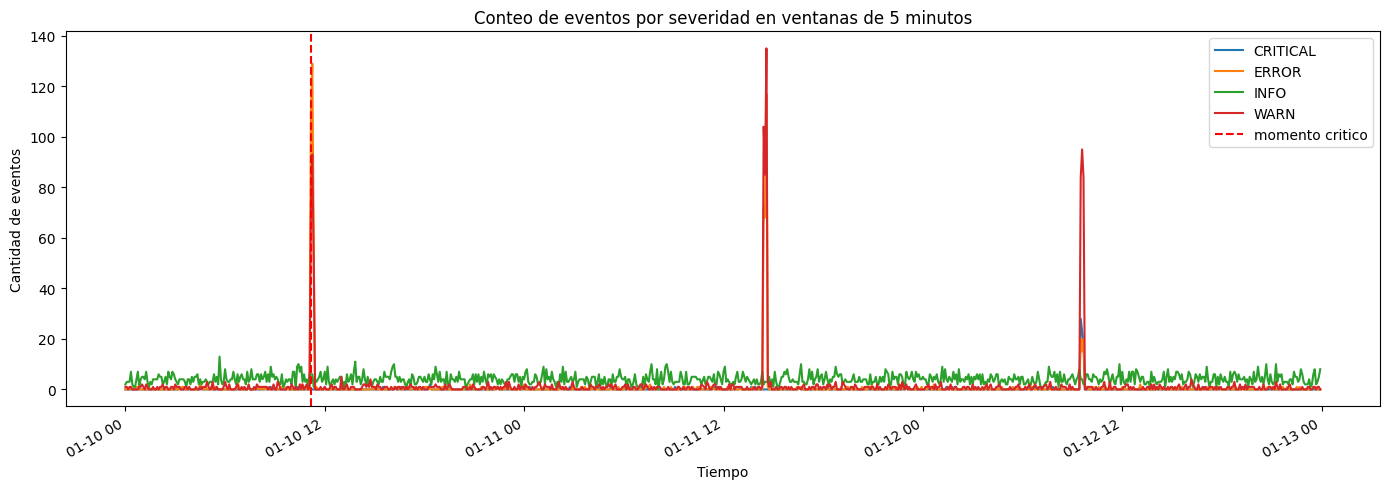

In [18]:
time_grouper = pd.Grouper(key='timestamp_event', freq='5min') # Agrupa los datos por ventana de tiempo
df_severity_bins = (df.groupby([time_grouper, 'severity'])
                    .agg(n_events = ('timestamp_event', 'count'))
                    .reset_index()
                    ) # Agrupa los datos por ventana de tiempo y cuenta el total de eventos y bad events
df_severity_pivot = df_severity_bins.pivot_table(
    index = 'timestamp_event',
    columns = 'severity',
    values = 'n_events',
    aggfunc = 'sum'
).fillna(0) # Rellena los valores nulos con 0

fig, ax = plt.subplots(figsize=(14, 5)) # Crea una figura y un eje para el gráfico

for col_severidad in df_severity_pivot.columns: # Itera sobre las columnas de severidad
    ax.plot(
        df_severity_pivot.index,
        df_severity_pivot[col_severidad],
        label = col_severidad
    ) # Grafica los datos

ax.axvline(
    x = dt_window_start,
    color = 'red',
    linestyle = '--',
    label = 'momento critico'
) # Grafica la línea vertical para el momento crítico

ax.set_title('Conteo de eventos por severidad en ventanas de 5 minutos') # Establece el título del gráfico
ax.set_xlabel('Tiempo') # Establece la etiqueta del eje x
ax.set_ylabel('Cantidad de eventos') # Establece la etiqueta del eje y
ax.legend() # Muestra la leyenda

fig.autofmt_xdate() # Formatea las fechas del eje x
plt.tight_layout() # Ajusta el diseño del gráfico
plt.show() # Muestra el gráfico

### Gráfico 2 (temporal):
bad_rate o %_5xx en bins de 5 min.

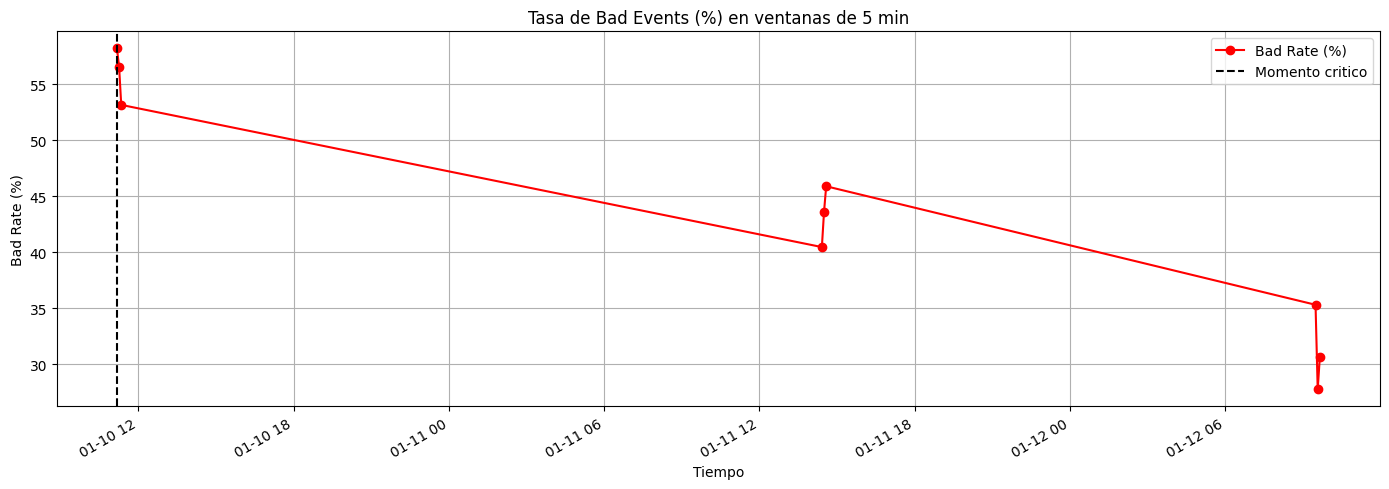

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df_windows_filtered['window_start'],
    df_windows_filtered['bad_rate'] * 100,
    label='Bad Rate (%)',
    color='red',
    marker='o'
)

ax.axvline(
    x=dt_window_start,
    color='black',
    linestyle='--',
    label='Momento critico'
)

ax.set_title('Tasa de Bad Events (%) en ventanas de 5 min')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Bad Rate (%)')
ax.legend()
ax.grid(True)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## Conclusiones

El análisis del dataset de logs permite construir la siguiente explicación sobre el incidente ocurrido en el sistema:

**Momento crítico:** La ventana con mayor actividad anómala fue **2026-01-10 entre las 11:10 y las 11:15 hs (UTC)**, con una bad_rate
de 0.58 sobre un total de 189 eventos, lo que la convierte en el peor momento del período analizado (filtro: ventanas con >= 20 eventos).

**Servicio más afectado:** `orders-service` concentró 72 de los 110 bad events del momento crítico, representando el 65% de todos los
eventos malos de esa ventana.

**Endpoint más comprometido:** `/orders/cancel` fue el endpoint con mayor cantidad de bad events (26), seguido de `/orders/create` (25)
y `/orders/status` (21). Criterio aplicado: cantidad de bad events.

**Mensaje dominante:** El error más frecuente dentro del momento crítico fue `"Order creation failed - inventory lock timeout"` con
72 ocurrencias, lo que sugiere un problema de bloqueos en el inventario como causa raíz del incidente.

**Comparación incidente vs baseline:** Durante el incidente la bad_rate fue de **0.58 vs 0.14 del baseline** (4x más alta), y la
latencia promedio pasó de **521 ms a 1590 ms** (3x más lenta), evidenciando una degradación severa y acotada en el tiempo.